Neste projeto investigo como diferentes técnicas de amostragem se comportam ao tentar
representar uma população. Utilizo a base Census Income (Adult Dataset, UCI), com 32561
registros, aplicando cinco técnicas clássicas: aleatória simples, sistemática, por grupos
(conglomerados), estratificada e de reservatório.

O ponto de partida foi um exercício de implementação dessas técnicas, mas implementar cada
técnica isoladamente não responde à pergunta que realmente importa em amostragem: qual
técnica preserva melhor as características da população, e essa preservação é consistente
ou depende da sorte da tiragem. Para responder isso, não basta rodar cada técnica uma única
vez, é preciso repetir cada uma delas várias vezes e observar a distribuição das estimativas
resultantes, não apenas um valor pontual.

Utilizo pandas para manipulação dos dados, numpy e o módulo random para as implementações
de amostragem, scikit-learn (`StratifiedShuffleSplit`) para a amostragem estratificada, e
matplotlib/seaborn para as visualizações comparativas.

O notebook está organizado da seguinte forma:

1. Imports e Configurações
2. Coleta e Inspeção dos Dados
3. Análise Exploratória
4. Visualizações
5. Conclusão e Considerações Finais
6. Referências

---

## 1. Imports e Configurações

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit

import session_info
import warnings

warnings.filterwarnings('ignore')
session_info.show(dependencies=False)

In [2]:
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#f1f5f9',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

---

## 2. Coleta e Inspeção dos Dados
Carrego a base Census Income e faço uma inspeção inicial: dimensões, tipos de dados e
formatação das colunas categóricas que vou utilizar como referência de representatividade
(`income` e `sex`). Uso aqui um espelho do dataset Adult Census Income hospedado no GitHub,
já que não tinha em mãos o `census.csv` original do curso. A estrutura e os valores são os
mesmos do dataset UCI, a única diferença visível é a convenção de nomes de colunas (ponto no
lugar de hífen, por exemplo `education.num`).

### 2.1 Visão geral do dataframe

In [ ]:
dataset = pd.read_csv('https://raw.githubusercontent.com/pooja2512/Adult-Census-Income/refs/heads/master/adult.csv')

In [5]:
# dimensões
dataset.shape

(32561, 15)

In [6]:
# primeiros registros
dataset.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


> A base tem 32561 registros e 15 colunas, confirmando o tamanho esperado. Colunas fora do
escopo desta análise, como `workclass` e `occupation`, usam `?` para marcar valores
ausentes, não trato isso aqui porque essas colunas não entram nas comparações de
representatividade.

### 2.2 Formatação das colunas categóricas de referência

Antes de calcular proporções, verifico os valores únicos de `income` e `sex`, já que bases
como esta costumam ter espaços em branco antes dos valores categóricos, o que quebraria
qualquer comparação de igualdade adiante.

In [7]:
dataset['income'].unique(), dataset['sex'].unique()

(<StringArray>
 ['<=50K', '>50K']
 Length: 2, dtype: str,
 <StringArray>
 ['Female', 'Male']
 Length: 2, dtype: str)

> Os valores já vêm limpos, sem espaços em branco (`<=50K`, `>50K`, `Female`, `Male`), o que
confirma que as comparações de igualdade usadas no restante do notebook funcionam sem
necessidade de tratamento adicional.

### 2.3 Estatísticas de referência da população

Calculo aqui os três valores que servem de "gabarito" ao longo do projeto: a idade média
real da população e as proporções reais de `income` e `sex`. Todas as comparações de
representatividade nas seções seguintes são feitas contra estes valores.

In [8]:
verdade_populacional = {
    'idade_media': dataset['age'].mean(),
    'prop_renda_alta': (dataset['income'] == '>50K').mean(),
    'prop_sexo_masculino': (dataset['sex'] == 'Male').mean()
}
verdade_populacional

{'idade_media': np.float64(38.58164675532078),
 'prop_renda_alta': np.float64(0.2408095574460244),
 'prop_sexo_masculino': np.float64(0.6692054912318418)}

> A idade média da população é 38,58 anos, 24,08% dos registros têm renda acima de 50 mil e
66,92% são do sexo masculino. Esses três valores são a referência usada em todas as
comparações de representatividade das próximas seções.


---

## 3. Análise Exploratória

### 3.1 Verificação da ordem do dataset

A amostragem por grupos assume que os grupos formados são heterogêneos, ou seja, que a
ordem das linhas no arquivo não segue nenhum padrão relacionado às variáveis de interesse.
Antes de testar essa técnica, verifico se isso é verdade, dividindo o dataset em blocos
sequenciais e observando se a proporção de renda alta varia de forma acentuada entre eles.

In [9]:
n_blocos = 20
tamanho_bloco = len(dataset) // n_blocos
tamanho_bloco

1628

In [10]:
proporcoes_por_bloco = []
for i in range(n_blocos):
    bloco = dataset.iloc[i * tamanho_bloco : (i + 1) * tamanho_bloco]
    proporcoes_por_bloco.append((bloco['income'] == '>50K').mean())

proporcoes_por_bloco

[np.float64(0.5417690417690417),
 np.float64(0.8722358722358723),
 np.float64(0.16339066339066338),
 np.float64(0.20577395577395577),
 np.float64(0.18304668304668303),
 np.float64(0.18857493857493857),
 np.float64(0.18243243243243243),
 np.float64(0.18304668304668303),
 np.float64(0.1977886977886978),
 np.float64(0.18243243243243243),
 np.float64(0.19594594594594594),
 np.float64(0.18857493857493857),
 np.float64(0.1769041769041769),
 np.float64(0.19901719901719903),
 np.float64(0.18857493857493857),
 np.float64(0.1977886977886978),
 np.float64(0.19533169533169534),
 np.float64(0.18796068796068796),
 np.float64(0.18488943488943488),
 np.float64(0.20085995085995087)]

> A proporção de renda alta varia de forma extrema entre os primeiros blocos, 54,2% no bloco 0
e 87,2% no bloco 1, caindo para uma faixa entre 16% e 20% em praticamente todos os blocos
seguintes, abaixo inclusive da proporção real da população (24,1%).
>
> Isso indica que a base não está em ordem aleatória, os primeiros registros concentram um perfil de renda mais alta
que o resto do dataset. Combinado com o fato de as primeiras linhas do `head()` mostrarem
idades decrescentes (90, 82, 66...), a hipótese mais provável é que o arquivo esteja
parcialmente ordenado por idade, o que arrasta a renda alta para o início. Essa quebra de
aleatoriedade é justamente a condição que a amostragem por grupos não tolera bem, o que se
confirma na simulação da seção 3.5.

### 3.2 Refatoração das técnicas de amostragem

As implementações originais do curso dependem do estado global do módulo `random`
(`random.seed`), o que é adequado para uma única tiragem, mas inviável para repetir cada
técnica centenas de vezes de forma controlada. Refatoro as cinco funções para aceitar um
`random_state` explícito por chamada.

Na amostragem sistemática, garanto também que o tamanho da amostra retornada seja sempre
exatamente igual ao solicitado, truncando os índices resultantes. Isso é necessário porque
o número de índices gerados por `np.arange` pode variar em uma unidade dependendo do ponto
de partida sorteado, e amostras de tamanhos diferentes não são comparáveis na simulação.

Na amostragem de reservatório, implemento o Algoritmo R (Vitter, 1985) diretamente, que é a
formulação padrão e mais simples do que a versão revisada no material do curso.

In [11]:
def amostragem_aleatoria_simples(dataset, tamanho, random_state):
    return dataset.sample(n=tamanho, random_state=random_state)


def amostragem_sistematica(dataset, tamanho, random_state):
    intervalo = len(dataset) // tamanho
    rng = random.Random(random_state)
    inicio = rng.randint(0, intervalo - 1)
    indices = np.arange(inicio, len(dataset), step=intervalo)[:tamanho]
    return dataset.iloc[indices]


def amostragem_agrupamento(dataset, numero_grupos, random_state):
    intervalo = len(dataset) / numero_grupos
    grupos = (np.arange(len(dataset)) // intervalo).astype(int)
    df = dataset.copy()
    df['grupo'] = grupos
    rng = random.Random(random_state)
    grupo_selecionado = rng.randint(0, numero_grupos - 1)
    amostra = df[df['grupo'] == grupo_selecionado].drop(columns='grupo')
    return amostra


def amostragem_estratificada(dataset, tamanho, coluna_estrato, random_state):
    percentual = tamanho / len(dataset)
    split = StratifiedShuffleSplit(n_splits=1, test_size=percentual, random_state=random_state)
    for _, indices_teste in split.split(dataset, dataset[coluna_estrato]):
        amostra = dataset.iloc[indices_teste]
    return amostra


def amostragem_reservatorio(dataset, tamanho, random_state):
    rng = random.Random(random_state)
    reservatorio = list(range(tamanho))
    for i in range(tamanho, len(dataset)):
        j = rng.randrange(i + 1)
        if j < tamanho:
            reservatorio[j] = i
    return dataset.iloc[reservatorio]

### 3.3 Execução única de cada técnica (sanidade)

Antes da simulação repetida, rodo cada técnica uma vez com `random_state=0` só para
confirmar que todas retornam o tamanho de amostra esperado.

In [12]:
tamanho_amostra = 100
numero_grupos = len(dataset) // tamanho_amostra

testes = {
    'Aleatória Simples': amostragem_aleatoria_simples(dataset, tamanho_amostra, 0),
    'Sistemática': amostragem_sistematica(dataset, tamanho_amostra, 0),
    'Por Grupos': amostragem_agrupamento(dataset, numero_grupos, 0),
    'Estratificada': amostragem_estratificada(dataset, tamanho_amostra, 'income', 0),
    'Reservatório': amostragem_reservatorio(dataset, tamanho_amostra, 0),
}

{nome: len(amostra) for nome, amostra in testes.items()}

{'Aleatória Simples': 100,
 'Sistemática': 100,
 'Por Grupos': 101,
 'Estratificada': 100,
 'Reservatório': 100}

> Todas as técnicas retornam exatamente 100 registros, com exceção da amostragem por grupos,
que devolveu 101. Isso é esperado, o tamanho de um grupo depende de quantos registros caem
naquele intervalo específico, não é fixado por parâmetro como nas demais técnicas.

### 3.4 Simulação: repetição das amostragens

Repito cada técnica 500 vezes, cada repetição com um `random_state` diferente, registrando
a idade média, a proporção de renda alta e a proporção de sexo masculino de cada amostra
gerada. É essa coleção de repetições, não uma tiragem isolada, que permite avaliar viés e
estabilidade de cada técnica.

In [13]:
def executar_simulacao(nome_metodo, funcao_amostragem, repeticoes=500, **kwargs):
    registros = []
    for rep in range(repeticoes):
        amostra = funcao_amostragem(dataset, random_state=rep, **kwargs)
        registros.append({
            'metodo': nome_metodo,
            'repeticao': rep,
            'idade_media': amostra['age'].mean(),
            'prop_renda_alta': (amostra['income'] == '>50K').mean(),
            'prop_sexo_masculino': (amostra['sex'] == 'Male').mean(),
        })
    return pd.DataFrame(registros)

In [19]:
resultados = pd.concat([
    executar_simulacao('Aleatória Simples', amostragem_aleatoria_simples, tamanho=tamanho_amostra),
    executar_simulacao('Sistemática', amostragem_sistematica, tamanho=tamanho_amostra),
    executar_simulacao('Por Grupos', amostragem_agrupamento, numero_grupos=numero_grupos),
    executar_simulacao('Estratificada', amostragem_estratificada, tamanho=tamanho_amostra, coluna_estrato='income'),
    executar_simulacao('Reservatório', amostragem_reservatorio, tamanho=tamanho_amostra),
], ignore_index=True)

resultados.shape

(2500, 5)

> A simulação gerou 2500 registros, 500 repetições para cada uma das cinco técnicas, cada
linha guardando a idade média e as proporções de renda alta e sexo masculino observadas
naquela repetição.

### 3.5 Viés e variabilidade por técnica

Para cada técnica e cada variável, calculo o viés (diferença entre a média das estimativas
e o valor real da população) e a variabilidade (desvio padrão das estimativas entre as 500
repetições). Viés baixo indica que a técnica acerta em média, variabilidade baixa indica que
ela é consistente entre execuções, as duas coisas juntas definem uma técnica confiável.

In [15]:
resumo = resultados.groupby('metodo').agg(
    idade_media_estimada=('idade_media', 'mean'),
    idade_desvio=('idade_media', 'std'),
    prop_renda_estimada=('prop_renda_alta', 'mean'),
    prop_renda_desvio=('prop_renda_alta', 'std'),
    prop_sexo_estimada=('prop_sexo_masculino', 'mean'),
    prop_sexo_desvio=('prop_sexo_masculino', 'std'),
)

resumo['idade_vies'] = resumo['idade_media_estimada'] - verdade_populacional['idade_media']
resumo['prop_renda_vies'] = resumo['prop_renda_estimada'] - verdade_populacional['prop_renda_alta']
resumo['prop_sexo_vies'] = resumo['prop_sexo_estimada'] - verdade_populacional['prop_sexo_masculino']

resumo

,idade_media_estimada,idade_desvio,prop_renda_estimada,prop_renda_desvio,prop_sexo_estimada,prop_sexo_desvio,idade_vies,prop_renda_vies,prop_sexo_vies
metodo,,,,,,,,,
Aleatória Simples,38.596060,1.467635,0.240260,0.040667,0.671240,0.046960,0.014413,-0.000550,0.002035
Estratificada,38.602220,1.316290,0.240000,0.000000,0.668560,0.045928,0.020573,-0.000810,-0.000645
Por Grupos,38.713474,2.811794,0.250123,0.211369,0.671392,0.071996,0.131827,0.009314,0.002187
Reservatório,38.694720,1.374961,0.240240,0.044125,0.672200,0.047759,0.113073,-0.000570,0.002995
Sistemática,38.627300,1.328217,0.243180,0.036808,0.672740,0.042825,0.045653,0.002370,0.003535


> A tabela confirma o que a verificação da ordem do dataset antecipou. A amostragem por
grupos tem o maior desvio em praticamente todas as métricas, 2,81 anos de desvio na idade
média (quase o dobro das demais técnicas, entre 1,3 e 1,47), e 0,211 de desvio na proporção
de renda alta, contra 0,037 a 0,044 nas outras quatro técnicas, uma variabilidade cerca de
cinco vezes maior. O viés médio da amostragem por grupos, no entanto, não é o maior (0,13
anos de idade, 0,9 ponto percentual de renda alta), porque ao repetir a simulação 500 vezes,
grupos com proporção muito acima e muito abaixo da real acabam se compensando na média. Isso
expõe a fragilidade real da técnica, ela não é sistematicamente tendenciosa, mas qualquer
execução isolada tem alta chance de ficar longe da verdade, o que a média de 500 repetições
esconde.
>
> A amostragem estratificada é a única com desvio zero na proporção de renda alta, resultado
esperado e não coincidência, a técnica fixa a quantidade de registros de cada classe antes de
sortear quais indivíduos entram na amostra, então toda repetição preserva exatamente a
proporção populacional dessa variável. O que muda entre repetições é apenas quem é sorteado
dentro de cada classe, por isso o desvio em idade (1,32) e sexo (0,046) segue próximo das
demais técnicas.
>
> A amostragem de reservatório chama atenção pelo viés de idade (0,113), mais que o dobro do
viés da aleatória simples (0,014) e da sistemática (0,046), embora ainda pequeno frente ao
desvio padrão da própria técnica (1,37). Não é um resultado alarmante, mas vale registrar
como uma observação a acompanhar caso o experimento seja reproduzido com mais repetições.
> 
> Sistemática e aleatória simples têm comportamento parecido entre si, desvios de 1,33 e 1,47
respectivamente, sem nenhuma anomalia relevante, o que é esperado já que nenhuma das duas
leva em conta a estrutura da base.

---

## 4. Visualizações

### 4.1 Estabilidade da idade média por técnica

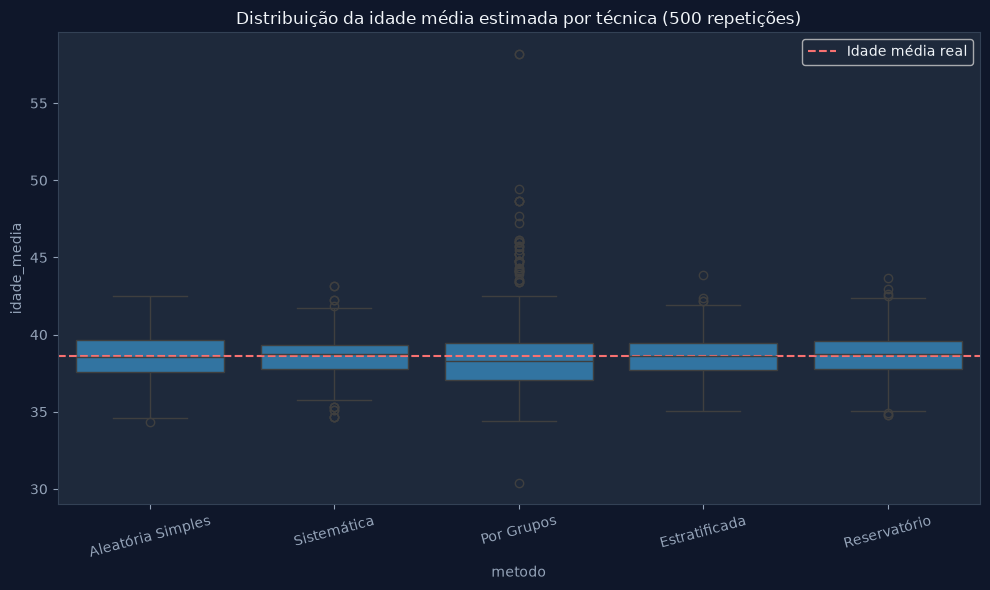

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=resultados, x='metodo', y='idade_media', ax=ax)
ax.axhline(verdade_populacional['idade_media'], color='#f87171', linestyle='--', label='Idade média real')
ax.set_title('Distribuição da idade média estimada por técnica (500 repetições)')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

> O boxplot confirma visualmente o que a tabela de desvios mostrou, a caixa da amostragem por
grupos é visivelmente mais larga que as demais, refletindo o desvio de 2,81 anos. As outras
quatro técnicas têm caixas de tamanho parecido, todas centradas próximo da linha de idade
média real.


### 4.2 Estabilidade da proporção de renda alta por técnica

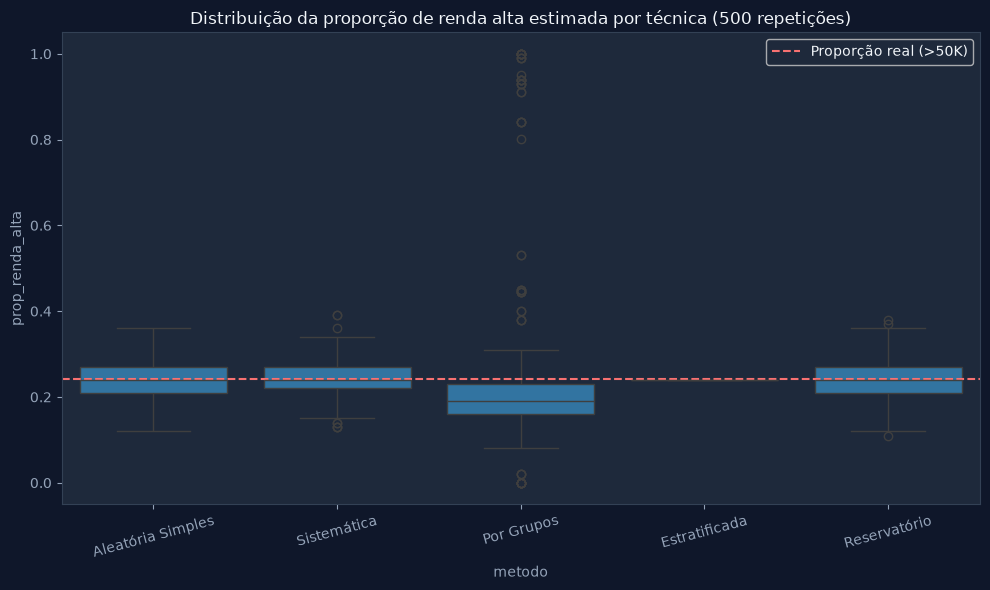

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=resultados, x='metodo', y='prop_renda_alta', ax=ax)
ax.axhline(verdade_populacional['prop_renda_alta'], color='#f87171', linestyle='--', label='Proporção real (>50K)')
ax.set_title('Distribuição da proporção de renda alta estimada por técnica (500 repetições)')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

> Aqui a diferença é ainda mais evidente, a caixa da amostragem por grupos se espalha por uma
faixa muito mais ampla que as demais, consequência direta da falta de aleatoriedade na ordem
da base. A amostragem estratificada aparece como uma linha praticamente sem espessura, todas
as 500 repetições caem no mesmo valor de proporção, confirmando o desvio zero calculado na
seção 3.5.

### 4.3 Proporção de renda alta por bloco sequencial do dataset

Complementa a verificação da seção 3.1: visualiza se a ordem das linhas explica a
instabilidade observada na amostragem por grupos.

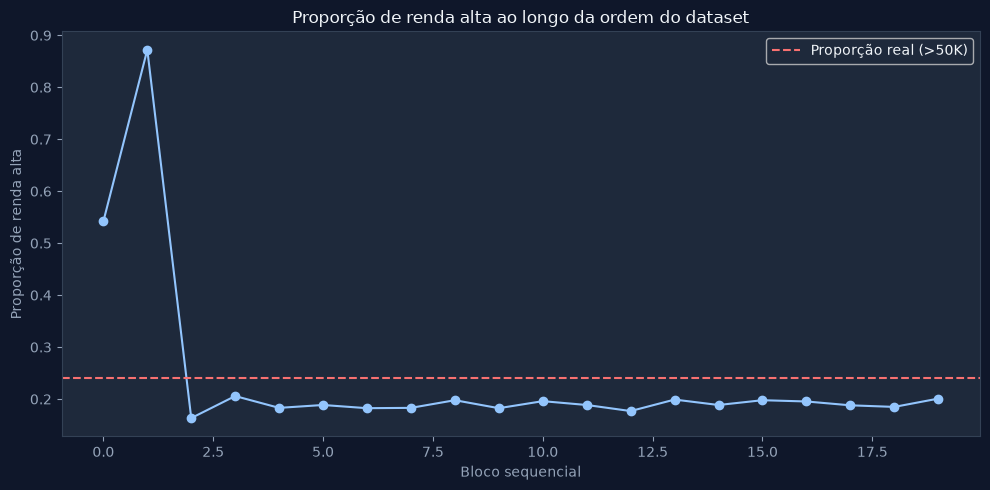

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(n_blocos), proporcoes_por_bloco, marker='o', color='#93c5fd')
ax.axhline(verdade_populacional['prop_renda_alta'], color='#f87171', linestyle='--', label='Proporção real (>50K)')
ax.set_xlabel('Bloco sequencial')
ax.set_ylabel('Proporção de renda alta')
ax.set_title('Proporção de renda alta ao longo da ordem do dataset')
ax.legend()
plt.tight_layout()
plt.show()

> O gráfico deixa claro o padrão, os dois primeiros blocos disparam acima da linha de
proporção real (54,2% e 87,2% contra 24,1%), e a partir do terceiro bloco a proporção se
estabiliza numa faixa entre 16% e 20%, consistentemente abaixo da média populacional. Essa
concentração no início da base é a causa direta da instabilidade da amostragem por grupos.

---

## 5. Conclusão e Considerações Finais

### 5.1 Síntese do Projeto

Neste projeto testei cinco técnicas de amostragem (aleatória simples, sistemática, por
grupos, estratificada e reservatório) na base Adult Census Income, repetindo cada uma 500
vezes para observar não só o viés médio de cada técnica, mas sua estabilidade entre
execuções.

Antes de simular, verifiquei se a ordem das linhas da base era aleatória, dividindo o
dataset em 20 blocos sequenciais e comparando a proporção de renda alta em cada um. Os dois
primeiros blocos mostraram proporções de 54,2% e 87,2%, muito acima da proporção real da
população (24,1%), enquanto o restante da base ficou consistentemente abaixo dela, entre 16%
e 20%. A base não está em ordem aleatória.

Essa falta de aleatoriedade se refletiu diretamente na simulação. A tabela abaixo resume o
resultado das 500 repetições por técnica:

| Técnica | Idade média estimada | Desvio (idade) | Proporção renda alta | Desvio (renda) |
|---|---|---|---|---|
| Aleatória Simples | 38,60 | 1,47 | 24,03% | 0,041 |
| Sistemática | 38,63 | 1,33 | 24,32% | 0,037 |
| Por Grupos | 38,71 | 2,81 | 25,01% | 0,211 |
| Estratificada | 38,60 | 1,32 | 24,00% | 0,000 |
| Reservatório | 38,69 | 1,37 | 24,02% | 0,044 |

Valor real da população: idade média 38,58 anos, proporção de renda alta 24,08%.

A amostragem estratificada foi a única a preservar a proporção de renda alta de forma exata
em todas as repetições, resultado direto de sua construção, que fixa a quantidade de
registros por classe antes de sortear os indivíduos. A amostragem por grupos foi a técnica
menos confiável, não pelo viés médio, que ficou próximo das demais, mas pela variabilidade,
cerca de cinco vezes maior que as outras quatro técnicas na proporção de renda alta. As
demais técnicas (aleatória simples, sistemática e reservatório) tiveram desempenho parecido
entre si, sem diferenças que se destacassem.

### 5.2 Achados relevantes

O achado central deste projeto não é sobre qual técnica é melhor em média, é sobre a
diferença entre viés e variabilidade. A amostragem por grupos teve viés médio pequeno (0,13
anos, 0,9 ponto percentual de renda), o que isoladamente sugeriria uma técnica confiável.
Mas esse viés baixo só aparece porque a média de 500 execuções compensa grupos com proporção
de renda alta muito acima e muito abaixo da real. Qualquer execução única dessa técnica,
como seria o caso em um projeto real que não repete a amostragem, tem alta chance de cair
num extremo, como os blocos que registraram 54% ou 87% de renda alta. Avaliar uma técnica de
amostragem só pelo viés médio esconde esse risco, a variabilidade entre execuções é uma
informação igualmente necessária.

### 5.3 Limitações e Considerações

Uso apenas um tamanho de amostra fixo (100 registros, cerca de 0,3% da população), não testei
se a instabilidade da amostragem por grupos diminui com amostras maiores. Também limitei a
verificação de representatividade a três variáveis (idade, renda e sexo), outras colunas da
base, como escolaridade ou ocupação, não foram checadas. A base usada é um espelho do
dataset Adult Census Income hospedado no GitHub, não o arquivo `census.csv` original do
curso, a estrutura e os valores são equivalentes, mas vale essa ressalva para fins de
reprodutibilidade. As colunas com valores ausentes marcados como `?` (`workclass`,
`occupation`, `native.country`) não foram tratadas, pois não fazem parte do escopo desta
análise.

Este projeto tem finalidade educacional, para consolidação de conceitos de amostragem
estatística e composição de portfólio.

---

## 6. Referências

- IA Expert Academy. Curso *Estatística para Ciência de Dados e Machine Learning*, seção
"População e amostra".
- Dua, D. and Graff, C. (2019). Adult (Census Income) Data Set. UCI Machine Learning
Repository.
- Espelho do dataset utilizado: [pooja2512/Adult-Census-Income](https://github.com/pooja2512/Adult-Census-Income) (GitHub).
- Vitter, J. S. (1985). Random sampling with a reservoir. *ACM Transactions on Mathematical
Software*.
- scikit-learn documentation, `StratifiedShuffleSplit`.

---

> Material desenvolvido para estudos e composição de portfólio a partir do curso
> [Estatística para Ciência de Dados e Machine Learning](https://iaexpert.academy/cursos-online-assinatura/estatistica-para-ciencia-de-dados-e-machine-learning/),
> para o repositório [data-trivium](https://github.com/esscova/data-trivium);
> com auxílio do Claude Anthropic para revisões e estruturação.